In [ ]:
pip install -U datasets huggingface_hub fsspec

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


In [ ]:
from datasets import load_dataset

#ds = load_dataset("SetFit/bbc-news")
#ds = load_dataset("SetFit/imdb")
ds = load_dataset("SetFit/20_newsgroups")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
from datasets import load_dataset, concatenate_datasets
train_ds = ds["train"]
test_ds  = ds["test"]

# 합치기
all_ds = concatenate_datasets([train_ds, test_ds])
print(all_ds)
df_all = all_ds.to_pandas()
print(df_all.head())

Dataset({
    features: ['text', 'label', 'label_text'],
    num_rows: 18846
})
                                                text  label  \
0  I was wondering if anyone out there could enli...      7   
1  A fair number of brave souls who upgraded thei...      4   
2  well folks, my mac plus finally gave up the gh...      4   
3  \nDo you have Weitek's address/phone number?  ...      1   
4  From article <C5owCB.n3p@world.std.com>, by to...     14   

              label_text  
0              rec.autos  
1  comp.sys.mac.hardware  
2  comp.sys.mac.hardware  
3          comp.graphics  
4              sci.space  


In [ ]:
df_all['text'][0]

'I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.'

#텍스트 정제

In [ ]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def tokenize_english_text(text):
    # 1) 허용할 문자만 남기기: 알파벳·숫자·밑줄·공백·.,?!
    text = re.sub(r'[^A-Za-z0-9\w\s,\.?!]', '', text)

    # 2) 소문자화 후 공백 기준 단어 분리
    tokens = text.lower().split()

    # 3) 불용어 제거
    filtered = [word for word in tokens if word not in stop_words]

    # 4) 다시 문자열로 결합
    return ' '.join(filtered)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df_all['clean_text'] = df_all['text'].apply(tokenize_english_text)

In [ ]:
df_all['clean_text'][0]

'wondering anyone could enlighten car saw day. 2door sports car, looked late 60s early 70s. called bricklin. doors really small. addition, front bumper separate rest body. know. anyone tellme model name, engine specs, years production, car made, history, whatever info funky looking car, please email.'

In [ ]:
df_all['text'][0]

'I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.'

In [ ]:
import spacy

# 영어 모델 로드 (한 번만 설치하세요: pip install spacy && python -m spacy download en_core_web_sm)
nlp = spacy.load("en_core_web_sm")

def lemmatize_spacy(text):
    doc = nlp(text)
    # token.lemma_ 가 표제어
    return " ".join([token.lemma_ for token in doc])

df_all['lemma_text'] = df_all['clean_text'].apply(lemmatize_spacy)

In [ ]:
df_all['text'][0]

'I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.'

In [ ]:
df_all['lemma_text'][0]

'wonder anyone could enlighten car see day . 2door sport car , look late 60 early 70 . call bricklin . door really small . addition , front bumper separate rest body . know . anyone tellme model name , engine spec , year production , car make , history , whatever info funky look car , please email .'

In [ ]:
(df_all['lemma_text'].str.len() == 0).sum()

529

In [ ]:
df_all = df_all[df_all['lemma_text'].str.len() !=0]

In [ ]:
pip install wordcloud

In [ ]:
from wordcloud import WordCloud, STOPWORDS

# 통계치

In [ ]:
#문자수
df_all['length'] = df_all['lemma_text'].str.split().map(len)
stats_by_label = df_all.groupby('label')['length'].describe()

print(stats_by_label)
# 1) 단어 수는 이미 구했으니, 문자열 길이(문자 수)도 계산해 보겠습니다.
df_all['char_length'] = df_all['lemma_text'].str.len()
# 또는
# df_all['char_length'] = df_all['lemma_text'].apply(len)

# 2) 앞 몇 개 값 확인
stats_by_label1 = df_all.groupby('label')['char_length'].describe()

# 3) 전체 통계량 보기
print(stats_by_label1)


       count        mean         std  min    25%   50%     75%     max
label                                                                 
0      779.0  131.623877  320.273122  1.0  30.00  61.0  124.50  5747.0
1      953.0  153.098636  645.605080  1.0  26.00  47.0   87.00  6660.0
2      947.0  119.044351  389.038801  1.0  27.00  49.0   89.00  8220.0
3      964.0   89.086100  188.326846  1.0  31.00  55.0   95.25  3252.0
4      927.0   79.943905  265.176674  1.0  28.00  48.0   84.00  5718.0
5      981.0  160.246687  612.013235  1.0  28.00  54.0  104.00  6748.0
6      959.0   89.622523  155.494784  1.0  28.00  50.0   91.50  2277.0
7      936.0   81.288462  148.703301  1.0  27.00  51.5   93.25  2949.0
8      969.0   70.832817  145.747528  1.0  22.00  42.0   87.00  4037.0
9      956.0   95.025105  138.764848  1.0  25.00  51.5  107.25  1849.0
10     974.0  150.812115  446.347270  1.0  30.25  61.0  122.00  9429.0
11     962.0  159.927235  415.114754  1.0  35.00  74.0  141.75  6284.0
12    

In [ ]:
df_all = df_all[df_all['length'] >= 5]

In [ ]:
len(df_all)

18100

In [ ]:
#STOPWORDS.update(['say', 'mr']) # BBCnews
#STOPWORDS.update(['br','s']) # IMDB
STOPWORDS.update(['say', '_','maxaxaxaxaxaxaxaxaxaxaxaxaxaxax','mg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9v','maxaxaxaxaxaxaxaxaxaxaxaxaxaxaxq']) # 20newsgroup

#wordcloud

In [ ]:

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 필요하다면 NLTK 불용어 세트를 추가로 병합
# from nltk.corpus import stopwords
# custom_stop = set(stopwords.words('english'))
# all_stop = STOPWORDS.union(custom_stop)

# 0~4 라벨을 순회하며 워드클라우드 생성
for label in sorted(df_all['label'].unique()):
    # 해당 라벨의 모든 텍스트를 하나의 문자열로 결합
    text = " ".join(df_all.loc[df_all['label'] == label, 'lemma_text'])

    # 워드클라우드 객체 생성
    wc = WordCloud(
        width=800,
        height=800,
        max_words=200,
        stopwords=STOPWORDS,     # 또는 stopwords=all_stop
        background_color="white"
    ).generate(text)

    # 플롯팅
    plt.figure(figsize=(8, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Label {label} WordCloud", fontsize=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import STOPWORDS

# 1) wordcloud STOPWORDS 를 리스트로 준비
wc_stop_list = list(STOPWORDS)

# 2) N-gram 함수 수정
def get_top_text_ngram(corpus, n, g, stop_words=None):
    # stop_words 인자가 없으면 wordcloud STOPWORDS 사용
    if stop_words is None:
        sw = wc_stop_list
    # set 타입이면 list 로, 그 외(이미 list거나 'english') 그대로
    elif isinstance(stop_words, set):
        sw = list(stop_words)
    else:
        sw = stop_words

    vec = CountVectorizer(
        ngram_range=(g, g),
        stop_words=sw
    )
    bag_of_words = vec.fit_transform(corpus)
    sum_words     = bag_of_words.sum(axis=0)
    words_freq    = [
        (word, sum_words[0, idx])
        for word, idx in vec.vocabulary_.items()
    ]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# 3) 라벨별 Unigram(top10) 뽑기 (wordcloud STOPWORDS 적용)
top_ngrams_by_label = {}
for label, grp in df_all.groupby('label'):
    corpus = grp['lemma_text'].tolist()
    top_ngrams = get_top_text_ngram(
        corpus,
        n=10,
        g=1,
        stop_words=None  # None 이면 기본으로 wc_stop_list 사용
    )
    top_ngrams_by_label[label] = top_ngrams

# 4) 결과 확인
for label, freqs in top_ngrams_by_label.items():
    print(f"\n=== Label {label} Top-10 Unigrams (with WordCloud STOPWORDS) ===")
    for word, cnt in freqs:
        print(f"{word}: {cnt}")


#bertopic

In [ ]:
!pip install BERTopic
!pip install bertopic[visualization] sentence-transformers
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 51.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.1 requires scipy>=1.14.0; python_v

In [ ]:
# 1) 라이브러리 설치 (한 번만)
# !pip install bertopic[visualization]
from sentence_transformers import SentenceTransformer
# 2) import
from bertopic import BERTopic
import pandas as pd

# 3) 문서 리스트 준비
docs = df_all['lemma_text'].tolist()

# 4) BERTopic 모델 생성
#    - n_gram_range: 토큰화 시 고려할 n-gram 범위 (예: (1, 2) → unigram+bigram)
#    - min_topic_size: 토픽 최소 문서 수
#    - nr_topics: 'auto' 또는 정수로 최종 토픽 개수 지정
model = BERTopic(
    language="english",
    n_gram_range=(1, 1),
    min_topic_size=10,
    nr_topics=13,
    calculate_probabilities=True
)

# 5) 토픽 학습 및 문서별 토픽 할당
topics, probabilities = model.fit_transform(docs)

# 6) 결과 확인
# 6.1) 문서별 토픽 번호, 확신도
df_all['topic']        = topics
import numpy as np
assigned_scores = [
    probabilities[i][topics[i]] if topics[i] != -1 else np.nan
    for i in range(len(topics))
]
df_all['topic_score'] = assigned_scores


# 6.2) 전체 토픽 정보 (토픽 ID, 문서 수, 주요 키워드)
topic_info = model.get_topic_info()
print(topic_info)

# 7) 토픽별 키워드 확인 (예: 토픽 0)
print(model.get_topic(0))

# 8) 토픽 분포 시각화 (인터랙티브)
fig1 = model.visualize_topics()
fig1.show()

# 9) 문서-토픽 비율 히트맵
fig2 = model.visualize_heatmap()
fig2.show()

# 10) 특정 문서의 토픽 분포
doc_index = 5
print("문서:", docs[doc_index])
print("할당된 토픽:", topics[doc_index])
print("토픽별 확신도:", probabilities[doc_index])


In [ ]:
model.reduce_topics(docs, nr_topics=5)
print(model.get_topic_info())

#sbert

In [ ]:
from sentence_transformers import SentenceTransformer, models
import numpy as np

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer, models
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora
import os
import random
import numpy as np
import torch
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# (1) 모델 + Pooling 구성
word_embedding_model = models.Transformer("sentence-transformers/all-MiniLM-L6-v2")
pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_cls_token = True,
    pooling_mode_max_tokens= True,
    pooling_mode_mean_tokens=  True
    )
embedding_model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

# (2) 임베딩 생성
docs = df_all['lemma_text'].tolist()
embeddings = embedding_model.encode(docs, batch_size=32, show_progress_bar=True, convert_to_numpy=True)

# (3) 저장
np.save("saved_embeddings.npy", embeddings)


Batches:   0%|          | 0/566 [00:00<?, ?it/s]

In [ ]:
# 결과값을 보고 싶을 때
# ==========================================
# SBERT 최적값 + 토픽별 상위 단어까지 출력 (최소 변경 버전)
# ==========================================
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer, models
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora
import os
import random
import numpy as np
import torch

# ================================
# 0) df_all, STOPWORDS, vectorizer_model 준비
# ================================
docs = df_all['lemma_text'].tolist()
vectorizer_model = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(1, 1),
    lowercase=True,
    token_pattern=r"(?u)\b\w\w+\b"
)

# ================================
# 1) Seed 고정
# ================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ================================
# 2) CountVectorizer 기준 토큰화 & Dictionary 생성
# ================================
analyzer = vectorizer_model.build_analyzer()
tokenized_for_coherence = [analyzer(doc) for doc in docs]
dictionary = corpora.Dictionary(tokenized_for_coherence)

# ================================
# 3) 저장된 임베딩 로드 (SBERT 임베딩 파일이어야 함)
# ================================
embeddings = np.load("saved_embeddings.npy")  # <- SBERT 임베딩이어야 함
assert embeddings.shape[0] == len(docs), "embeddings 개수와 docs 개수가 다릅니다!"

# ================================
# 4) nr_topics 루프 돌며 평가
# ================================
results = []
for n in tqdm(range(2, 25, 2), desc="Evaluating nr_topics"):
    model_n = BERTopic(
        embedding_model=None,          # 임베딩 직접 주입
        vectorizer_model=vectorizer_model,
        min_topic_size=10,
        nr_topics=n,
        calculate_probabilities=False
        # , random_state=SEED  # 재현성 필요하면 주석 해제
    )
    topics_n, probs_n = model_n.fit_transform(docs, embeddings=embeddings)

    # (B) 토픽 수 (outlier -1 제외)
    topic_info = model_n.get_topic_info()
    n_clusters = topic_info[topic_info.Topic != -1].shape[0]

    # (C) coherence & diversity 계산
    topic_dict = model_n.get_topics()
    valid_tids = sorted([t for t in topic_dict if t != -1])

    if not valid_tids:
        overall_cv = overall_cn = diversity = 0.0
    else:
        # 대표 토픽 단어 리스트
        topic_words = [[w for w, _ in topic_dict[tid]] for tid in valid_tids]

        # coherence 계산 (CountVectorizer 기준 토큰화 사용)
        cm_cv = CoherenceModel(
            topics=topic_words,
            texts=tokenized_for_coherence,
            dictionary=dictionary,
            coherence='c_v'
        )
        cm_cn = CoherenceModel(
            topics=topic_words,
            texts=tokenized_for_coherence,
            dictionary=dictionary,
            coherence='c_npmi'
        )
        overall_cv = cm_cv.get_coherence()
        overall_cn = cm_cn.get_coherence()

        # topic diversity
        all_top = [w for tw in topic_words for w in tw[:10]]
        diversity = len(set(all_top)) / (10 * len(topic_words))

    results.append({
        'nr_topics':        n,
        'n_clusters':       n_clusters,
        'coherence_c_v':    overall_cv,
        'coherence_c_npmi': overall_cn,
        'topic_diversity':  diversity
    })

# ================================
# 5) 결과 DataFrame화 및 최적값 출력
# ================================
df_results = pd.DataFrame(results)
print(df_results)

mean_values = df_results.mean(numeric_only=True)
mean_row = pd.DataFrame(mean_values).T
mean_row.index = ['mean']
df_results = pd.concat([df_results, mean_row], axis=0)
print(df_results)

valid_df = df_results.drop(index='mean')
best_cv = valid_df['coherence_c_v'].idxmax()
best_cn = valid_df['coherence_c_npmi'].idxmax()
best_div = valid_df['topic_diversity'].idxmax()

print(f"\n▶ coherence_c_v 최고: nr_topics = {int(valid_df.loc[best_cv, 'nr_topics'])}, "
      f"value = {valid_df.loc[best_cv, 'coherence_c_v']:.4f}")
print(f"▶ coherence_c_npmi 최고: nr_topics = {int(valid_df.loc[best_cn, 'nr_topics'])}, "
      f"value = {valid_df.loc[best_cn, 'coherence_c_npmi']:.4f}")
print(f"▶ topic_diversity 최고: nr_topics = {int(valid_df.loc[best_div, 'nr_topics'])}, "
      f"value = {valid_df.loc[best_div, 'topic_diversity']:.4f}")

# ================================
# (추가) '단어들이 나오는 결과값' 출력
# - c_v 기준 최적 nr_topics로 재적합 후, 토픽별 상위 단어 출력
# ================================
TOP_N = 10
best_n_cv = int(valid_df.loc[best_cv, 'nr_topics'])

model_best_cv = BERTopic(
    embedding_model=None,
    vectorizer_model=vectorizer_model,
    min_topic_size=10,
    nr_topics=best_n_cv,
    calculate_probabilities=False
    # , random_state=SEED  # 재현성 필요시
)
_ = model_best_cv.fit_transform(docs, embeddings=embeddings)

print(f"\n[c_v 기준 최적 nr_topics={best_n_cv}] 토픽별 상위 {TOP_N} 단어")
for tid in sorted(t for t in model_best_cv.get_topics().keys() if t != -1):
    top_terms = [w for w, _ in model_best_cv.get_topic(tid)[:TOP_N]]
    print(f"Topic {tid:>3}: " + ", ".join(top_terms))

# ================================
# (선택) c_npmi 기준 최적 nr_topics도 단어 출력
# nr_topics가 c_v와 다를 때만 추가 리핏
# ================================
best_n_cn = int(valid_df.loc[best_cn, 'nr_topics'])
if best_n_cn != best_n_cv:
    model_best_cn = BERTopic(
        embedding_model=None,
        vectorizer_model=vectorizer_model,
        min_topic_size=10,
        nr_topics=best_n_cn,
        calculate_probabilities=False
        # , random_state=SEED
    )
    _ = model_best_cn.fit_transform(docs, embeddings=embeddings)

    print(f"\n[c_npmi 기준 최적 nr_topics={best_n_cn}] 토픽별 상위 {TOP_N} 단어")
    for tid in sorted(t for t in model_best_cn.get_topics().keys() if t != -1):
        top_terms = [w for w, _ in model_best_cn.get_topic(tid)[:TOP_N]]
        print(f"Topic {tid:>3}: " + ", ".join(top_terms))

# (선택) 표 형태로 보고 싶으면 아래 주석 해제
# rows = [{"topic": tid, "top_words": ", ".join([w for w, _ in model_best_cv.get_topic(tid)[:TOP_N]])}
#         for tid in sorted(t for t in model_best_cv.get_topics().keys() if t != -1)]
# print("\n[c_v 기준] 토픽-단어 표")
# print(pd.DataFrame(rows))


Evaluating nr_topics:   0%|          | 0/12 [00:00<?, ?it/s]

    nr_topics  n_clusters  coherence_c_v  coherence_c_npmi  topic_diversity
0           2           1       0.600545          0.030352         1.000000
1           4           3       0.502724         -0.004531         1.000000
2           6           5       0.561399          0.045394         1.000000
3           8           7       0.524658          0.047424         0.985714
4          10           9       0.551295          0.071649         0.977778
5          12          11       0.530923          0.058803         0.981818
6          14          13       0.549579          0.070705         0.953846
7          16          15       0.502514          0.039400         0.940000
8          18          17       0.482723          0.026502         0.929412
9          20          19       0.569537          0.075363         0.947368
10         22          21       0.551269          0.048912         0.957143
11         24          23       0.579547          0.086009         0.934783
      nr_top

In [ ]:
 #
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer, models
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora
import os
import random
import numpy as np
import torch

# ================================
# 0) df_all, STOPWORDS, vectorizer_model 준비
# ================================
docs = df_all['lemma_text'].tolist()
vectorizer_model = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(1, 1),
    lowercase=True,
    token_pattern=r"(?u)\b\w\w+\b"
)

# ================================
# 1) Seed 고정
# ================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ================================
# 2) CountVectorizer 기준 토큰화 & Dictionary 생성
# ================================
analyzer = vectorizer_model.build_analyzer()
tokenized_for_coherence = [analyzer(doc) for doc in docs]
dictionary = corpora.Dictionary(tokenized_for_coherence)

# ================================
# 3) 저장된 임베딩 로드
# ================================
embeddings = np.load("saved_embeddings.npy")
assert embeddings.shape[0] == len(docs), "embeddings 개수와 docs 개수가 다릅니다!"

# ================================
# 4) nr_topics 루프 돌며 평가
# ================================
results = []
for n in tqdm(range(2, 25, 2), desc="Evaluating nr_topics"):
    model_n = BERTopic(
        embedding_model=None,          # 임베딩 직접 주입
        vectorizer_model=vectorizer_model,
        min_topic_size=10,
        nr_topics=n,
        calculate_probabilities=False
    )
    topics_n, probs_n = model_n.fit_transform(docs, embeddings=embeddings)

    # (B) 토픽 수 (outlier -1 제외)
    topic_info = model_n.get_topic_info()
    n_clusters = topic_info[topic_info.Topic != -1].shape[0]

    # (C) coherence & diversity 계산
    topic_dict = model_n.get_topics()
    valid_tids = sorted([t for t in topic_dict if t != -1])

    if not valid_tids:
        overall_cv = overall_cn = diversity = 0.0
    else:
        # 대표 토픽 단어 리스트
        topic_words = [[w for w, _ in topic_dict[tid]] for tid in valid_tids]

        # coherence 계산 (CountVectorizer 기준 토큰화 사용)
        cm_cv = CoherenceModel(
            topics=topic_words,
            texts=tokenized_for_coherence,
            dictionary=dictionary,
            coherence='c_v'
        )
        cm_cn = CoherenceModel(
            topics=topic_words,
            texts=tokenized_for_coherence,
            dictionary=dictionary,
            coherence='c_npmi'
        )
        overall_cv = cm_cv.get_coherence()
        overall_cn = cm_cn.get_coherence()

        # topic diversity
        all_top = [w for tw in topic_words for w in tw[:10]]
        diversity = len(set(all_top)) / (10 * len(topic_words))

    results.append({
        'nr_topics':        n,
        'n_clusters':       n_clusters,
        'coherence_c_v':    overall_cv,
        'coherence_c_npmi': overall_cn,
        'topic_diversity':  diversity
    })

# ================================
# 5) 결과 DataFrame화 및 최적값 출력
# ================================
df_results = pd.DataFrame(results)
print(df_results)

mean_values = df_results.mean(numeric_only=True)
mean_row = pd.DataFrame(mean_values).T
mean_row.index = ['mean']
df_results = pd.concat([df_results, mean_row], axis=0)
print(df_results)

valid_df = df_results.drop(index='mean')
best_cv = valid_df['coherence_c_v'].idxmax()
best_cn = valid_df['coherence_c_npmi'].idxmax()
best_div = valid_df['topic_diversity'].idxmax()

print(f"\n▶ coherence_c_v 최고: nr_topics = {int(valid_df.loc[best_cv, 'nr_topics'])}, "
      f"value = {valid_df.loc[best_cv, 'coherence_c_v']:.4f}")
print(f"▶ coherence_c_npmi 최고: nr_topics = {int(valid_df.loc[best_cn, 'nr_topics'])}, "
      f"value = {valid_df.loc[best_cn, 'coherence_c_npmi']:.4f}")
print(f"▶ topic_diversity 최고: nr_topics = {int(valid_df.loc[best_div, 'nr_topics'])}, "
      f"value = {valid_df.loc[best_div, 'topic_diversity']:.4f}")


Evaluating nr_topics:   0%|          | 0/12 [00:00<?, ?it/s]

    nr_topics  n_clusters  coherence_c_v  coherence_c_npmi  topic_diversity
0           2           1       0.600545          0.030352         1.000000
1           4           3       0.557558         -0.002567         0.966667
2           6           5       0.625998          0.053898         0.980000
3           8           7       0.460096         -0.005605         1.000000
4          10           9       0.546264          0.069901         0.977778
5          12          11       0.524831          0.054196         0.945455
6          14          13       0.562769          0.060757         0.969231
7          16          15       0.572280          0.075294         0.933333
8          18          17       0.522180          0.075926         0.935294
9          20          19       0.607360          0.114379         0.957895
10         22          21       0.586464          0.084237         0.957143
11         24          23       0.566726          0.081308         0.952174
      nr_top

In [ ]:
# 2) import
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer,models
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora
import os
import random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 2) Pooling 모듈 커스터마이징
pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_cls_token= True,    # CLS pooling 켜기
    pooling_mode_max_tokens=False,  # 최고값 pooling 끄기
    pooling_mode_mean_tokens=False  # Mean pooling 끄기
)

# 3) SentenceTransformer 객체 생성
#    여기선 CLS pooling만 쓰는 예시
embedding_model = SentenceTransformer(
    modules=[word_embedding_model, pooling_model]
)

# ▶ Mean pooling만 쓰고 싶다면:
# pooling_model = models.Pooling(
#     word_embedding_model.get_word_embedding_dimension(),
#     pooling_mode_cls_token=False,
#     pooling_mode_mean_tokens=True
# )

# 4) 문서 리스트 준비
docs = df_all['lemma_text'].tolist()
tokenized_docs = [doc.split() for doc in df_all['lemma_text']]
STOPWORDS.update([''])

# 2) CountVectorizer 생성 (여기서 불용어 제거, ngram_range 지정)
vectorizer_model = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(1, 1),           # unigram
    lowercase=True,
    token_pattern=r"(?u)\b\w\w+\b"
)
dictionary = corpora.Dictionary(tokenized_docs)
# 3) BERTopic 생성 시 vectorizer_model만 넘기기
results = []
for n in tqdm(range(2, 25,2), desc="Evaluating nr_topics"):
    # (A) 모델 학습
    model_n = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        min_topic_size=10,
        nr_topics=n,
        calculate_probabilities=True
    )
    topics_n, probs_n = model_n.fit_transform(docs)

    # (B) 토픽 수 계산 (outlier 토픽 -1 제외)
    topic_info = model_n.get_topic_info()            # DataFrame with columns ['Topic','Count',...]
    n_clusters = topic_info[topic_info.Topic != -1].shape[0]

    # (C) 키워드 추출 및 coherence/diversity 계산
    topic_dict = model_n.get_topics()
    topic_words = [
        [w for w, _ in topic_dict[tid]]
        for tid in sorted([t for t in topic_dict if t != -1])
    ]

    cm_cv = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    cm_cn = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_npmi'
    )
    overall_cv = cm_cv.get_coherence()
    overall_cn = cm_cn.get_coherence()

    all_top = [w for tw in topic_words for w in tw[:10]]
    diversity = len(set(all_top)) / (10 * len(topic_words))

    # (D) 결과 기록
    results.append({
        'nr_topics':        n,
        'n_clusters':       n_clusters,
        'coherence_c_v':    overall_cv,
        'coherence_c_npmi': overall_cn,
        'topic_diversity':  diversity
    })

# 5) DataFrame 정리 및 출력
df_results = pd.DataFrame(results)
print(df_results)
mean_values = df_results.mean(numeric_only=True)
mean_row = pd.DataFrame(mean_values).T
mean_row.index = ['mean']
df_results = pd.concat([df_results, mean_row], axis=0)

# 결과 출력
print(df_results)

# (F) 각 메트릭별 최적 nr_topics 찾기 (mean 행 제외)
valid_df = df_results.drop(index='mean')

best_cv = valid_df['coherence_c_v'].idxmax()
best_cn = valid_df['coherence_c_npmi'].idxmax()
best_div = valid_df['topic_diversity'].idxmax()

print(f"\n▶ coherence_c_v가 가장 높은 모델: nr_topics = {best_cv}, 값 = {valid_df.loc[best_cv, 'coherence_c_v']:.4f}")
print(f"▶ coherence_c_npmi가 가장 높은 모델: nr_topics = {best_cn}, 값 = {valid_df.loc[best_cn, 'coherence_c_npmi']:.4f}")
print(f"▶ topic_diversity가 가장 높은 모델: nr_topics = {best_div}, 값 = {valid_df.loc[best_div, 'topic_diversity']:.4f}")

Evaluating nr_topics:   0%|          | 0/12 [00:00<?, ?it/s]

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer, models
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora
from umap import UMAP
import pandas as pd

# 0) 문서·토큰 준비
docs            = df_all['lemma_text'].tolist()
tokenized_docs  = [doc.split() for doc in docs]
STOPWORDS.update(['say','make','mr'])

# 1) SentenceTransformer + Vectorizer 설정
word_embedding_model = models.Transformer("sentence-transformers/all-MiniLM-L6-v2")
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_cls_token=True,
    pooling_mode_max_tokens=False,
    pooling_mode_mean_tokens=False
)
embedding_model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

vectorizer_model = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(1,1),
    lowercase=True,
    token_pattern=r"(?u)\b\w\w+\b"
)
dictionary = corpora.Dictionary(tokenized_docs)

# 2) 실험 파라미터
embed_dims       = range(2, 25, 2)   # UMAP n_components
nr_topics_range  = range(2, 25, 2)   # BERTopic nr_topics
results = []

# 3) 중첩 루프: embedding_dim × nr_topics
for emb_dim in tqdm(embed_dims, desc="Embedding dims"):
    umap_model = UMAP(n_components=emb_dim, random_state=42)
    for n_topics in nr_topics_range:
        model = BERTopic(
            embedding_model=embedding_model,
            vectorizer_model=vectorizer_model,
            min_topic_size=10,
            nr_topics=n_topics,
            calculate_probabilities=True
        )
        topics, probs = model.fit_transform(docs)

        # 토픽 단어 추출
        topic_dict  = model.get_topics()
        topic_words = [
            [w for w,_ in topic_dict[tid]]
            for tid in sorted(t for t in topic_dict if t != -1)
        ]

        # c_v
        cm_cv = CoherenceModel(
            topics=topic_words,
            texts=tokenized_docs,
            dictionary=dictionary,
            coherence='c_v'
        )
        cv_score = cm_cv.get_coherence()

        # c_npmi
        cm_cn = CoherenceModel(
            topics=topic_words,
            texts=tokenized_docs,
            dictionary=dictionary,
            coherence='c_npmi'
        )
        cn_score = cm_cn.get_coherence()

        # diversity
        top_words = [w for tw in topic_words for w in tw[:10]]
        diversity = len(set(top_words)) / (10 * len(topic_words))

        results.append({
            'embed_dim':         emb_dim,
            'nr_topics':         n_topics,
            'coherence_c_v':     cv_score,
            'coherence_c_npmi':  cn_score,
            'topic_diversity':   diversity
        })

# 4) DataFrame 변환 & 요약
df = pd.DataFrame(results)

# (1) embed_dim별 평균/최고값
summary = df.groupby('embed_dim').agg(
    mean_cv   = ('coherence_c_v',    'mean'),
    max_cv    = ('coherence_c_v',    'max'),
    mean_cn   = ('coherence_c_npmi', 'mean'),
    max_cn    = ('coherence_c_npmi', 'max'),
    mean_div  = ('topic_diversity',  'mean'),
    max_div   = ('topic_diversity',  'max'),
).reset_index()

print("▶ Embed dim별 평균/최고값\n", summary)

# (2) 전체 중 최적 조합
best_cv_row   = df.loc[df['coherence_c_v'].idxmax()]
best_cn_row   = df.loc[df['coherence_c_npmi'].idxmax()]
best_div_row  = df.loc[df['topic_diversity'].idxmax()]

print("\n▶ 전체 중 최고 c_v 조합:",  best_cv_row.to_dict())
print("▶ 전체 중 최고 c_npmi 조합:", best_cn_row.to_dict())
print("▶ 전체 중 최고 diversity 조합:", best_div_row.to_dict())


ImportError: cannot import name 'size' from 'scipy._lib._array_api' (/usr/local/lib/python3.11/dist-packages/scipy/_lib/_array_api.py)

    nr_topics  n_clusters  coherence_c_v  coherence_c_npmi  topic_diversity
0           2           2       0.568068          0.101692             0.95
1           3           2       0.568068          0.101692             0.95
2           4           2       0.568068          0.101692             0.95
3           5           2       0.568068          0.101692             0.95
4           6           2       0.568068          0.101692             0.95
5           7           2       0.568068          0.101692             0.95
6           8           2       0.568068          0.101692             0.95
7           9           2       0.568068          0.101692             0.95
8          10           2       0.568068          0.101692             0.95
9          11           2       0.568068          0.101692             0.95
10         12           2       0.568068          0.101692             0.95
11         13           2       0.568068          0.101692             0.95
12         1

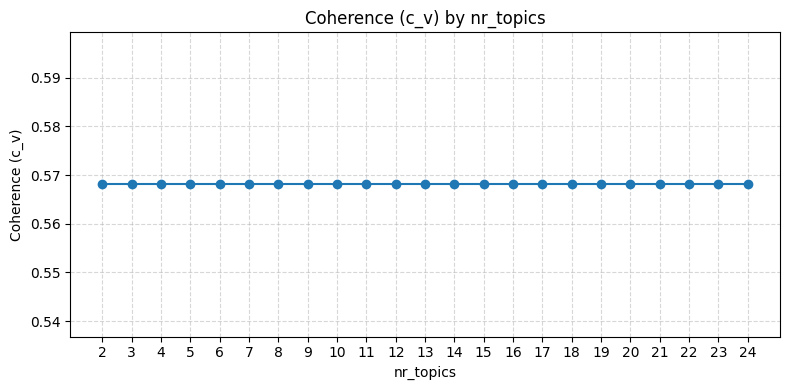

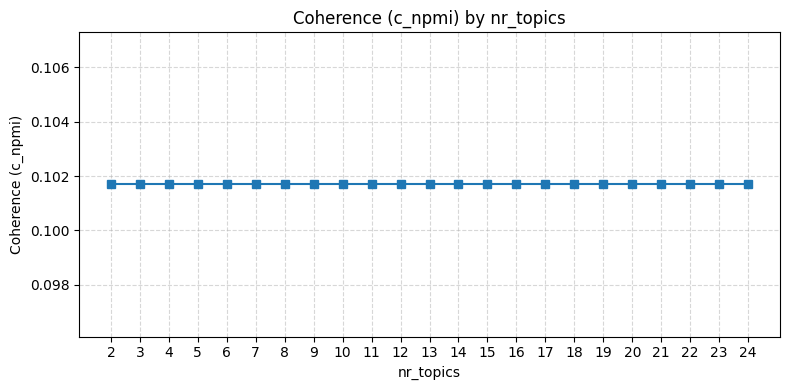

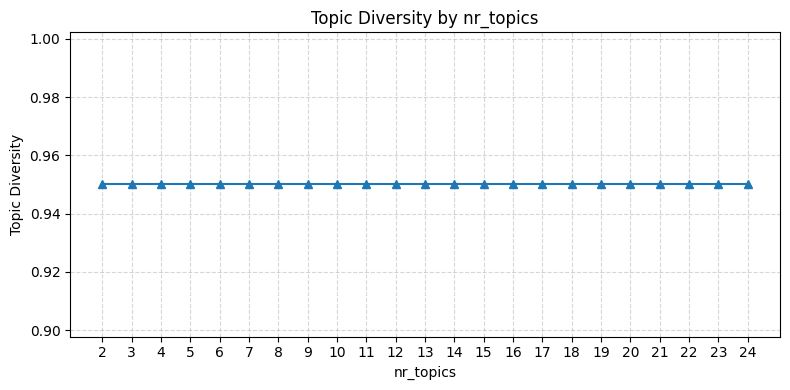

In [ ]:
print(df_results)
import matplotlib.pyplot as plt

# Assuming df_results DataFrame is already defined with columns:
# 'nr_topics', 'coherence_c_v', 'coherence_c_npmi', 'topic_diversity'

# 1) coherence_c_v plot
plt.figure(figsize=(8, 4))
plt.plot(df_results['nr_topics'], df_results['coherence_c_v'], marker='o')
plt.xlabel('nr_topics')
plt.ylabel('Coherence (c_v)')
plt.title('Coherence (c_v) by nr_topics')
plt.xticks(df_results['nr_topics'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2) coherence_c_npmi plot
plt.figure(figsize=(8, 4))
plt.plot(df_results['nr_topics'], df_results['coherence_c_npmi'], marker='s')
plt.xlabel('nr_topics')
plt.ylabel('Coherence (c_npmi)')
plt.title('Coherence (c_npmi) by nr_topics')
plt.xticks(df_results['nr_topics'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3) topic_diversity plot
plt.figure(figsize=(8, 4))
plt.plot(df_results['nr_topics'], df_results['topic_diversity'], marker='^')
plt.xlabel('nr_topics')
plt.ylabel('Topic Diversity')
plt.title('Topic Diversity by nr_topics')
plt.xticks(df_results['nr_topics'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#lda


In [ ]:
from gensim.models import LdaModel
from tqdm.auto import tqdm
# 2) import
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer,models
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora
import os
import random
import numpy as np
import torch
# 1) Transformer 레이어 로드
word_embedding_model = models.Transformer("sentence-transformers/all-MiniLM-L6-v2")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 4) 문서 리스트 준비
docs = df_all['lemma_text'].tolist()
tokenized_docs = [doc.split() for doc in docs]

# → STOPWORDS 초기화
STOPWORDS = set()
STOPWORDS.update(['say', 'make', 'mr'])
tokenized_docs = [
    [word for word in doc if word not in STOPWORDS]
    for doc in tokenized_docs
]
dictionary = corpora.Dictionary(tokenized_docs)
# → BOW corpus 생성
corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

# --- 5) nr_topics 범위별 성능 평가 (LDA) ---
results = []
for n in tqdm(range(2, 25, 2), desc="Evaluating nr_topics with LDA"):
    # (A) LDA 모델 학습
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=n,
        random_state=SEED,
        passes=10,          # 필요에 따라 더 올리셔도 됩니다
        alpha='auto',
        per_word_topics=False
    )

    # (B) 토픽 단어 추출
    topic_words = [
        [word for word, _ in lda_model.show_topic(topic_id, topn=10)]
        for topic_id in range(n)
    ]
    n_clusters = n  # LDA는 항상 num_topics 개의 클러스터를 생성

    # (C) coherence/diversity 계산 (BERTopic과 동일)
    cm_cv = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    cm_cn = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_npmi'
    )
    overall_cv = cm_cv.get_coherence()
    overall_cn = cm_cn.get_coherence()

    all_top = [w for tw in topic_words for w in tw[:10]]
    diversity = len(set(all_top)) / (10 * len(topic_words))

    results.append({
        'nr_topics':        n,
        'n_clusters':       n_clusters,
        'coherence_c_v':    overall_cv,
        'coherence_c_npmi': overall_cn,
        'topic_diversity':  diversity
    })

# --- 6) 결과 정리 및 출력 (이전과 동일) ---
df_results = pd.DataFrame(results)
print(df_results)

mean_values = df_results.mean(numeric_only=True)
df_mean = pd.DataFrame([mean_values], index=['mean'])
df_results = pd.concat([df_results, df_mean], axis=0)
print(df_results)

valid_df = df_results.drop(index='mean')
best_cv  = valid_df['coherence_c_v'].idxmax()
best_cn  = valid_df['coherence_c_npmi'].idxmax()
best_div = valid_df['topic_diversity'].idxmax()

print(f"▶ coherence_c_v 최고: nr_topics={best_cv}, {valid_df.loc[best_cv,'coherence_c_v']:.4f}")
print(f"▶ coherence_c_npmi 최고: nr_topics={best_cn}, {valid_df.loc[best_cn,'coherence_c_npmi']:.4f}")
print(f"▶ topic_diversity 최고: nr_topics={best_div}, {valid_df.loc[best_div,'topic_diversity']:.4f}")


Evaluating nr_topics with LDA:   0%|          | 0/12 [00:00<?, ?it/s]

    nr_topics  n_clusters  coherence_c_v  coherence_c_npmi  topic_diversity
0           2           2       0.334828         -0.009886         0.750000
1           4           4       0.399972          0.010966         0.700000
2           6           6       0.459640          0.032691         0.700000
3           8           8       0.485169          0.042550         0.750000
4          10          10       0.489386          0.030944         0.780000
5          12          12       0.488049          0.017958         0.783333
6          14          14       0.547022          0.072457         0.778571
7          16          16       0.474214         -0.002397         0.756250
8          18          18       0.450183         -0.019793         0.777778
9          20          20       0.490070          0.000818         0.800000
10         22          22       0.486908          0.007801         0.790909
11         24          24       0.491936          0.010664         0.783333
      nr_top

# LLM

In [ ]:
!pip install -q transformers accelerate sentencepiece
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: read).
The token `llama` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/hugg

In [ ]:
import torch
# 프로세스별 사용량 표 (현재 프로세스가 얼마 쓰는지 확인)
if torch.cuda.is_available():
    print(torch.cuda.list_gpu_processes(0))
    print(torch.cuda.memory_summary(abbreviated=True))


GPU:0
no processes are running
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|--------------------------------

In [ ]:
import torch
import gc
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.ipc_collect()
gc.collect()

85

In [ ]:
# save_llama_embeddings.py

import os
import random
import numpy as np
import pandas as pd
import torch

from sentence_transformers import SentenceTransformer, models

# =====================================================
# 0) 환경 변수 & Seed 고정
# =====================================================

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# =====================================================
# 1) Llama 임베딩 레이어 로드
# =====================================================
word_embedding_model = models.Transformer(
    model_name_or_path="meta-llama/Llama-3.2-1B",
    model_args={
        "torch_dtype": torch.float32,
        "device_map": "auto",
        "trust_remote_code": True
    }
)
tokenizer = word_embedding_model.tokenizer
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    word_embedding_model.auto_model.config.pad_token_id = tokenizer.eos_token_id

# =====================================================
# 2) 풀링 모듈 설정 (mean pooling)
# =====================================================
pooling_model = models.Pooling(
    word_embedding_dimension=word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_cls_token=True,
    pooling_mode_max_tokens=False,
    pooling_mode_mean_tokens=False
)

# =====================================================
# 3) SentenceTransformer 객체 생성
# =====================================================
embedding_model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

# =====================================================
# 4) 문서 로드 및 임베딩 계산
# =====================================================
# df_all 파일 경로를 알맞게 수정하세요

docs = df_all['lemma_text'].tolist()

# 배치 크기나 show_progress_bar는 필요에 맞게 조정 가능합니다.
embeddings = embedding_model.encode(
    docs,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

# =====================================================
# 5) 임베딩 저장
# =====================================================
os.makedirs("embeddings", exist_ok=True)
save_path = "embeddings/saved_llama_embeddings.npy"
np.save(save_path, embeddings)

print(f"✅ {embeddings.shape[0]}개의 문서 임베딩을 '{save_path}'에 저장했습니다.")


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Batches:   0%|          | 0/566 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 142.36 GiB. GPU 0 has a total capacity of 79.32 GiB of which 52.84 GiB is free. Process 62168 has 26.47 GiB memory in use. Of the allocated memory 25.97 GiB is allocated by PyTorch, and 27.22 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# save_llama_embeddings.py
import os, random, numpy as np, pandas as pd, torch
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, models

# =====================================================
# 0) 환경 변수 & Seed 고정
# =====================================================

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# =====================================================
# 1) Llama 임베딩 레이어 로드 (max_length=512)
# =====================================================
CHUNK_SIZE = 512          # 한 청크 최대 토큰 수
STRIDE = 64               # 청크 간 겹침(컨텍스트 보전)

word_embedding_model = models.Transformer(
    model_name_or_path="meta-llama/Llama-3.2-1B",
    max_seq_length=CHUNK_SIZE,                    # <-- 여기!
    model_args={
        "torch_dtype": torch.float32,
        "device_map": "auto",
        "trust_remote_code": True
    }
)

tokenizer = word_embedding_model.tokenizer
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    word_embedding_model.auto_model.config.pad_token_id = tokenizer.eos_token_id

# 안전하게 토크나이저도 512로 고정
try:
    tokenizer.model_max_length = CHUNK_SIZE
except Exception:
    pass

# =====================================================
# 2) 풀링 모듈 설정 (권장: mean pooling)
#    * cls 풀링 유지 원하면 pooling_mode_cls_token=True로 바꾸세요.
# =====================================================
pooling_model = models.Pooling(
    word_embedding_dimension=word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_cls_token=True,
    pooling_mode_max_tokens=True,
    pooling_mode_mean_tokens= True
)

# =====================================================
# 3) SentenceTransformer 객체 생성
# =====================================================
embedding_model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

# =====================================================
# 유틸: 토큰 단위로 텍스트를 512/stride로 청크
# =====================================================
def chunk_text_by_tokens(text: str, tokenizer, max_len=512, stride=64):
    # special token은 내부에서 자동 추가되도록 여기서는 제거
    ids = tokenizer.encode(text, add_special_tokens=False)
    chunks = []
    i = 0
    n = len(ids)
    if n == 0:
        return [""], [0]
    while i < n:
        piece = ids[i:i+max_len]
        chunks.append(tokenizer.decode(piece, skip_special_tokens=True))
        if i + max_len >= n:
            break
        i += max_len - stride
    # 각 청크의 실제 토큰 길이(가중 평균에 사용)
    lens = [len(tokenizer.encode(c, add_special_tokens=False)) for c in chunks]
    return chunks, lens

# =====================================================
# 4) 문서 로드 및 임베딩 계산 (청크 → 임베딩 → 가중평균)
# =====================================================
# df_all 은 사용자 환경에 맞춰 로드되어 있어야 합니다.
docs = df_all['lemma_text'].tolist()

emb_list = []
with torch.no_grad():
    for doc in tqdm(docs, desc="Encoding with 512-token chunks"):
        chunks, lens = chunk_text_by_tokens(doc, tokenizer, CHUNK_SIZE, STRIDE)

        # 청크들을 배치로 인코딩
        chunk_embs = embedding_model.encode(
            chunks,
            batch_size=16,                 # 환경에 맞게 조정
            convert_to_numpy=True,
            show_progress_bar=False
        )

        # 토큰 수 가중 평균(정보량 비례 결합)
        w = np.asarray(lens, dtype=np.float32)
        if w.sum() == 0:                   # 빈 문서 예외 처리
            w = np.ones_like(w)
        w = w / w.sum()
        doc_emb = (chunk_embs * w[:, None]).sum(axis=0)

        emb_list.append(doc_emb)

embeddings = np.vstack(emb_list)

# =====================================================
# 5) 임베딩 저장
# =====================================================
os.makedirs("embeddings", exist_ok=True)
save_path = "embeddings/saved_llama_embeddings.npy"
np.save(save_path, embeddings)
print(f"✅ {embeddings.shape[0]}개의 문서 임베딩을 '{save_path}'에 저장했습니다. (512 토큰 청크, stride={STRIDE})")


Encoding with 512-token chunks: 100%|██████████| 18100/18100 [13:47<00:00, 21.88it/s]


✅ 18100개의 문서 임베딩을 'embeddings/saved_llama_embeddings.npy'에 저장했습니다. (512 토큰 청크, stride=64)


In [ ]:
from bertopic import BERTopic
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora
import numpy as np
import random
import torch
import os

# 0) Seed 고정
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 1) 데이터 로드

docs = df_all['lemma_text'].tolist()
tokenized_docs = [doc.split() for doc in docs]

# 2) 불용어, 벡터라이저, 사전 준비
vectorizer_model = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(1,1),
    lowercase=True,
    token_pattern=r"(?u)\b\w\w+\b"
)
dictionary = corpora.Dictionary(tokenized_docs)

# 3) 저장된 임베딩 로드
embeddings = np.load("embeddings/saved_llama_embeddings.npy")
assert embeddings.shape[0] == len(docs), "임베딩 개수와 문서 개수가 불일치합니다!"

# 4) nr_topics 평가 루프
results = []
for n in tqdm(range(2, 25, 2), desc="Evaluating nr_topics"):
    model_n = BERTopic(
        embedding_model=None,       # ★ precomputed embeddings 사용
        vectorizer_model=vectorizer_model,
        min_topic_size=10,
        nr_topics=n,
        calculate_probabilities=False
    )
    topics_n, _ = model_n.fit_transform(docs, embeddings=embeddings)

    # 토픽 수 계산
    info = model_n.get_topic_info()
    n_clusters = info[info.Topic != -1].shape[0]

    # coherence & diversity 계산
    topics = model_n.get_topics()
    tids   = sorted([t for t in topics if t != -1])
    if not tids:
        cv = cn = div = 0.0
    else:
        words = [[w for w,_ in topics[t]] for t in tids]
        cm_cv = CoherenceModel(topics=words, texts=tokenized_docs, dictionary=dictionary, coherence='c_v')
        cm_cn = CoherenceModel(topics=words, texts=tokenized_docs, dictionary=dictionary, coherence='c_npmi')
        cv = cm_cv.get_coherence()
        cn = cm_cn.get_coherence()
        all_top = [w for tw in words for w in tw[:10]]
        div = len(set(all_top)) / (10 * len(words))

    results.append({
        'nr_topics':       n,
        'n_clusters':      n_clusters,
        'coherence_c_v':   cv,
        'coherence_c_npmi':cn,
        'topic_diversity': div
    })

# 5) 결과 정리 및 최적값 출력
df_res = pd.DataFrame(results)
print(df_res)
mean_row = pd.DataFrame(df_res.mean(numeric_only=True)).T
mean_row.index = ['mean']
df_res = pd.concat([df_res, mean_row])
print(df_res)

valid = df_res.drop(index='mean')
best_cv  = valid['coherence_c_v'].idxmax()
best_cn  = valid['coherence_c_npmi'].idxmax()
best_div = valid['topic_diversity'].idxmax()

print(f"▶ coherence_c_v 최고: nr_topics = {valid.loc[best_cv,'nr_topics']}, 값 = {valid.loc[best_cv,'coherence_c_v']:.4f}")
print(f"▶ coherence_c_npmi 최고: nr_topics = {valid.loc[best_cn,'nr_topics']}, 값 = {valid.loc[best_cn,'coherence_c_npmi']:.4f}")
print(f"▶ topic_diversity 최고: nr_topics = {valid.loc[best_div,'nr_topics']}, 값 = {valid.loc[best_div,'topic_diversity']:.4f}")


Evaluating nr_topics:   0%|          | 0/12 [00:00<?, ?it/s]

    nr_topics  n_clusters  coherence_c_v  coherence_c_npmi  topic_diversity
0           2           1       0.535940          0.017280         1.000000
1           4           3       0.412251         -0.084718         1.000000
2           6           5       0.443584         -0.060472         0.860000
3           8           7       0.526014         -0.000307         0.871429
4          10           9       0.507302         -0.001088         0.855556
5          12          11       0.466058          0.004659         0.845455
6          14          13       0.512140          0.002879         0.807692
7          16          15       0.492507         -0.021302         0.820000
8          18          17       0.491588          0.006471         0.800000
9          20          19       0.545506          0.030639         0.831579
10         22          21       0.528579          0.025443         0.823810
11         24          23       0.598664          0.082872         0.765217
      nr_top

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer, models
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora
import torch
from huggingface_hub import login
import os
import numpy as np
import random


# (0) df_all 로드 예시
# df_all = pd.read_csv("your_corpus.csv")
# df_all 에 'lemma_text' 컬럼이 있어야 합니다.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# --- 1) Llama 임베딩 레이어 로드 ---
word_embedding_model = models.Transformer(
    model_name_or_path="meta-llama/Llama-3.2-1B",
    model_args={
        "torch_dtype": torch.float32,
        "device_map": "auto",
        "trust_remote_code": True
    }
)
tokenizer = word_embedding_model.tokenizer
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    # autoreload 하는 경우, 모델에도 반영해야 할 수 있습니다:
    word_embedding_model.auto_model.config.pad_token_id = tokenizer.eos_token_id

# --- 2) 풀링 모듈 설정 (mean pooling) ---
pooling_model = models.Pooling(
    word_embedding_dimension=word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_cls_token=False,
    pooling_mode_max_tokens = True,
    pooling_mode_mean_tokens= True
)

# --- 3) SentenceTransformer 객체 생성 ---
embedding_model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

# --- 4) 문서 리스트 및 벡터화 준비 ---
docs = df_all['lemma_text'].tolist()
tokenized_docs = [doc.split() for doc in docs]
STOPWORDS = set()  # 전에 정의해 두셨다면 이 줄은 제거하세요.
STOPWORDS.update(['say', 'make', 'mr'])

vectorizer_model = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(1, 1),
    lowercase=True,
    token_pattern=r"(?u)\b\w\w+\b"
)
dictionary = corpora.Dictionary(tokenized_docs)

# --- 5) nr_topics 범위별 성능 평가 ---
results = []
for n in tqdm(range(2, 25, 2), desc="Evaluating nr_topics"):
    model_n = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        min_topic_size=10,
        nr_topics=n,
        calculate_probabilities=True
    )
    # 괄호 한 개만 닫습니다!
    topics_n, probs_n = model_n.fit_transform(docs)

    # (B) 토픽 수 계산
    topic_info = model_n.get_topic_info()
    n_clusters = topic_info[topic_info.Topic != -1].shape[0]

    # (C) coherence/diversity 계산
    topic_dict = model_n.get_topics()
    topic_words = [
        [w for w, _ in topic_dict[tid]]
        for tid in sorted(t for t in topic_dict if t != -1)
    ]

    cm_cv = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    cm_cn = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_npmi'
    )
    overall_cv = cm_cv.get_coherence()
    overall_cn = cm_cn.get_coherence()

    all_top = [w for tw in topic_words for w in tw[:10]]
    diversity = len(set(all_top)) / (10 * len(topic_words))

    results.append({
        'nr_topics':        n,
        'n_clusters':       n_clusters,
        'coherence_c_v':    overall_cv,
        'coherence_c_npmi': overall_cn,
        'topic_diversity':  diversity
    })

# 6) 결과 정리 및 출력
df_results = pd.DataFrame(results)
print(df_results)

mean_values = df_results.mean(numeric_only=True)
df_mean = pd.DataFrame([mean_values], index=['mean'])
df_results = pd.concat([df_results, df_mean], axis=0)
print(df_results)

valid_df = df_results.drop(index='mean')
best_cv  = valid_df['coherence_c_v'].idxmax()
best_cn  = valid_df['coherence_c_npmi'].idxmax()
best_div = valid_df['topic_diversity'].idxmax()

print(f"▶ coherence_c_v 최고: nr_topics={best_cv}, {valid_df.loc[best_cv,'coherence_c_v']:.4f}")
print(f"▶ coherence_c_npmi 최고: nr_topics={best_cn}, {valid_df.loc[best_cn,'coherence_c_npmi']:.4f}")
print(f"▶ topic_diversity 최고: nr_topics={best_div}, {valid_df.loc[best_div,'topic_diversity']:.4f}")
